**### K-MEANS 2D (ANNUAL INCOME & SPENDING SCORE)**

**1. Import Library dan Load Dataset**

Di bagian cell pertama, kita mengimport library python yang dibutuhkan dan load Dataset Mall Customernya

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset Mall Customer yang telah di upload
df = pd.read_csv('../dataset/Mall_Customers.csv')

# Melihat 5 data pertama (teratas)
df.head()

# Untuk Kolom Genre, seharusnya bernama kolom 'Gender', akan tetapi dataset yang saya
# Dapat memang berasal dari sananya

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**2. Mengecek Struktur Data Mall Customer Analyzer Dataset dan Cek Missing Values**

Pada Cell 2, kali ini kita membuat struktur data dan missing value dengan tujuan mendapatkan nilai penuh di bagian pengolahan data, disini kita wajib membuktikan kalau data kita ini masih bersih dan tidak ada yang bolong atau hilang

In [7]:
# Cek informasi tipe data dan jumlah baris
print("Informasi Dataset")
df.info()

# Mengecek apakah ada data yang kosong (Missing Values)
print("\nJumlah Missing Values Per Kolom:")
print(df.isnull().sum())

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Jumlah Missing Values Per Kolom:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


**3. Pemisahan Fitur X or Feature Selection**

Fungsinya untuk mengambil dua kolom yang akan digunakan untuk training, yang pertama kolom Annual Income(k$) dan yang kedua kolom Spending Score(1 - 100)

In [8]:
# Kita mengambil kolom sebelumnya, kemudian kita menyimpan ke variabel X,
# Ini akan bertindak seperti alias supaya kita tidak perlu memanggil df (dataframe) yang panjang lagi

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Mengintip isi alias dari X ini
print("Struktur data X (Fitur yang digunakan):")
print((X.head()))

Struktur data X (Fitur yang digunakan):
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


**4. Scaling Fitur menggunakan Standar Scaler**

Berguna untuk meratakan isi dari kolom Annual Income dengan Spending Score supaya model K-Means tidak berat sebelah (tidak condong ke Annual Income), maka digunakanlah StandarScaler yang akan mengubah distribusi angka supaya kita punya rata-rata = 0 dan standar deviasi = 1

In [9]:
from sklearn.preprocessing import StandardScaler

# Inisialiasi
scaler = StandardScaler()

# Scaling pada data X dan simpan ke variabel yang baru (X_scaled)
X_scaled = scaler.fit_transform(X)

# Mengecek 5 data pertama yang telah di scale
print("5 Data pertama yang sudah di scale:")
print(X_scaled[:5]) # [:5] = 5 data pertama

5 Data pertama yang sudah di scale:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


**5. Menentukan K Cluster menggunakan Elbow Method (Intertia) dan Silhouette Score**

Di Cell 5 ini, daripada kita asal menentukan berapa nilai jumlah K Cluster yang diinginkan berdasarkan mood, lebih baik kita menggunakan Elbow Method (Berbentuk Lengan Manusia) dan Silhoutte Score (Bukti kuantitatif dari rata-rata jarak dan kedekatan jarak)

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Menyiapkan list untuk menampung hasil perhitungan
inertias = [] # Untuk menampung nilai Elbow Method (Intertia)
sil_scores = [] # Untuk menampung nilai Silhoutte Score

# Uji nilai k dari 2 sampai 10
k_range = range(2, 11)

for k in k_range:
    # Inisialisasi model KMeans
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)

    # 1. Ambil nilai inertias untuk Elbow Method
    inertias.append(kmeans.inertia_)

    # 2. Hitung nilai Silhoutte Score
    score = silhouette_score(X_scaled, kmeans.labels_)
    sil_scores.append(score)

print("Perhitungan Elbow Method (Intertia):")
print(inertias)

print("\nPerhitungan Silhoutte Score:")
print(sil_scores)

Perhitungan Elbow Method (Intertia):
[269.69101219276405, 157.70400815035939, 108.92131661364358, 65.56840815571681, 55.057348270385965, 44.86475569922555, 37.22818767758587, 32.39226763033118, 29.981897788243703]

Perhitungan Silhoutte Score:
[0.3212707813918878, 0.46658474419000145, 0.4939069237513199, 0.5546571631111091, 0.5398800926790663, 0.5281492781108291, 0.4552147906587443, 0.4570853966942764, 0.4431713026508046]


**6. Visualisasi Grafik Elbow Method (Inertia) dan Silhoutte Score**

Setelah melakukan perhitungan, kita tampilkan kedua grafik secara berdampingan untuk menemukan titik temu optimalnya

Tanda-Tanda Menentukan K Cluster:

Grafik Elbow: Mencari posisi dimana penurunannya mulai melandai drastis sehingga membentuk siku lengan

Grafik Silhoutte: Mencari puncak grafik atau nilai K tertinggi dan paling dekat ke angka 1

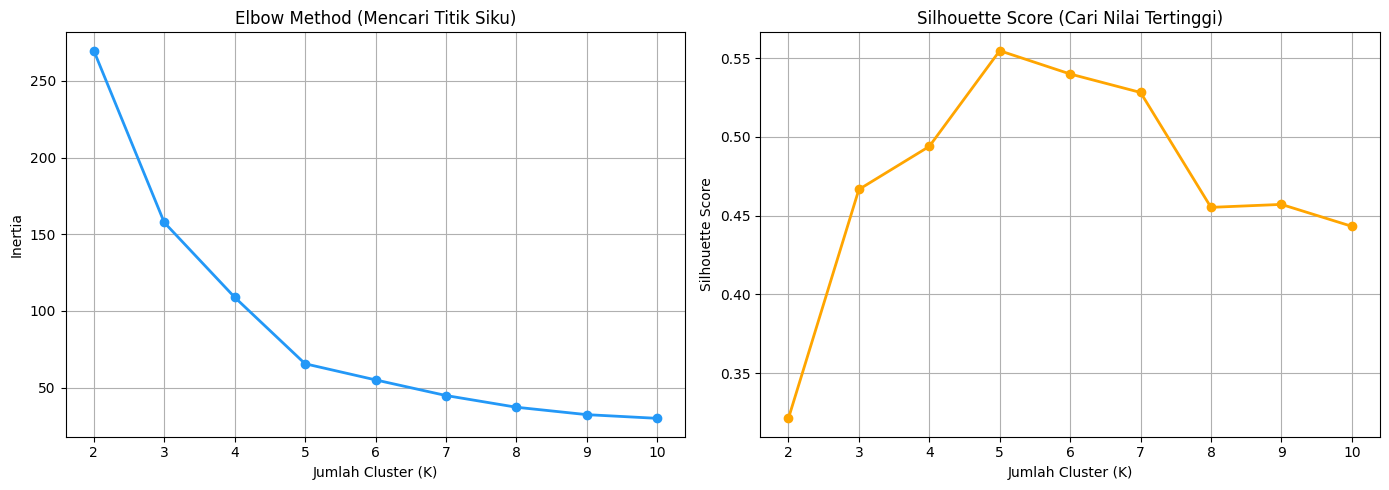

In [11]:
plt.figure(figsize=(14, 5))

# Plot 1: Elbow Method
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o', color='#2398f7', linewidth=2)
plt.title('Elbow Method (Mencari Titik Siku)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True) # Kalau Misalkan False garis-garis di background gk bakal ada alias polos

# Plot 2: Silhoutte Score
plt.subplot(1, 2, 2)
plt.plot(k_range, sil_scores, marker='o', color='orange', linewidth=2)
plt.title('Silhouette Score (Cari Nilai Tertinggi)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)

plt.tight_layout()
plt.show()

**7. Melatih Model K-Means (K = 5)**

Setelah kita melakukan preprocessing, load data, dan menentukan jumlah nilai K Clusternya, kita lakukan Pelatihan Model K-Means!

In [12]:
from sklearn.cluster import KMeans

# 1. Pembuatan model dengan 5 cluster sesuai hasil analisis Elbow Method dan Silhoutte Score
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)

# 2. Training model sekaligus memprediksi cluster untuk tiap baris data
y_kmeans = kmeans.fit_predict(X_scaled)

print("Hasil Prediksi Cluster:")
print(y_kmeans)

Hasil Prediksi Cluster:
[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


**8. Memasukkan Hasil Cluster Kembali ke Dataset Aseli**

Dari Variabel y_kmeans pada Cell 7 berisi array dari 0 sampai 4, yang artinya terdapat 5 kelompok. Supaya kita bisa baca dengan mudah siapa yang masuk kelompok mana (dari 5 kelompok tsb), kita memasukkan array ini menjadi kolom baru di dataset asli kita (df)

In [13]:
# Memasukkan label cluster ke dataset asli sebagai kolom baru bernama 'Cluster'
df['Cluster'] = y_kmeans

# Cek 5 data pertama untuk memastikan kolomnya benar benar sudah masuk (berada di paling kanan)
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


**9. Visualisasi Hasil Clustering**

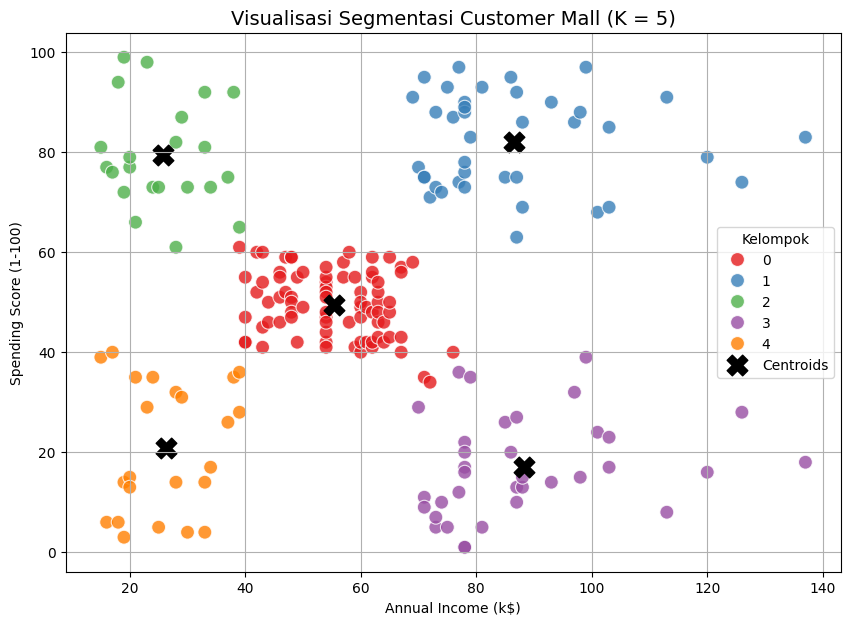

In [14]:
plt.figure(figsize=(10, 7))

# 1. Plot data poin untuk tiap cluster menggunakan data asli
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=100,
    alpha=0.8
)

# 2. Hitung rata-rata tiap cluster di data asli untuk mencari posisi Centroid asli
centroids = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

# 3. Plot titik Centroid di atas grafik
plt.scatter(
    centroids['Annual Income (k$)'],
    centroids['Spending Score (1-100)'],
    s=220,
    c='black',
    marker='X',
    label='Centroids'
)

# 4. Merapikan tampilan grafik
plt.title('Visualisasi Segmentasi Customer Mall (K = 5)', fontsize=14)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Kelompok')
plt.grid(True)

plt.show()

**10. Mapping Nama Cluster**

Di Cell 9 sebelumnya, kita mempunyai 5 kelompok yang mana dari kelompok 0 - 4, Untuk orang awam atau Manajemen Mall kemungkinan akan kebingungan dengan Label ini dikarenakan kita butuh Makna yang Rill atau Asli supaya Label dari masing-masing kelompok punya makna atau arti yang dapat dipahami

In [15]:
# 1. Mengubah angka 0-4 menjadi 1-5
df['Cluster_Nomor'] = df['Cluster'] + 1

# 2. Membuat Dictionary untuk mengubah angka menjadi nama makna
cluster_labels = {
    0: "Moderat (Standard)",
    1: "Sultan Boros (Target Utama)",
    2: "Impulsif",
    3: "Bijak (Rich & Frugal)",
    4: "Ekonomis (Hemat)"
}

# 3. Terapkan nama makna dari dictionary diatas ke kolom baruy bernama "Segmen_Customer"
df['Segmen_Customer'] = df['Cluster'].map(cluster_labels)

# Cek Hasil
df[['Annual Income (k$)', 'Spending Score (1-100)', 'Cluster_Nomor', 'Segmen_Customer']].head()

,Annual Income (k$),Spending Score (1-100),Cluster_Nomor,Segmen_Customer
0,15,39,5,Ekonomis (Hemat)
1,15,81,3,Impulsif
2,16,6,5,Ekonomis (Hemat)
3,16,77,3,Impulsif
4,17,40,5,Ekonomis (Hemat)


**11. Eksperimen Prediksi Data Baru (Predict)**

Pada Cell ini, kita akan membuat prediksi data baru, yang mana ketika user akan menginput data baru nanti dan prediksinya benar, maka program ini akan jauh lebih interaktif dibanding sebelumnya

In [16]:
# Disini kita akan membuat data dummy 2 customer baru yang mau belanja di mall
# Cust A: Pendapatan $15k, Skor Spending 80 (Harusnya masuk ke Kategori Impulsif)
# Cust B: Pendapatan $100k, Skor Spending 20 (Harusnya masuk ke Kategori Bijak/Frugal)

X_new = np.array([
    [15, 80],
    [100, 20]
])

# 1. Wajib di-scale terlebih dahulu dengan scaler yang sama(Menggunakan .transform)
X_new_scaled = scaler.transform(X_new)

# 2. Tembak ke model final kita untuk mendapatkan angka clusternya (0-4)
predict_new = kmeans.predict(X_new_scaled)

# 3. Ubah angka cluster tadi menjadi nama segmen yang telah kita bikin di dictionary(cluster_labels) sebelumnya
for i, cluster in enumerate(predict_new):
  segment_name = cluster_labels[cluster]
  print(f"Customer Baru ke-{i+1} dengan data {X_new[i]} diprediksi masuk ke segmen: {segment_name}")

Customer Baru ke-1 dengan data [15 80] diprediksi masuk ke segmen: Impulsif
Customer Baru ke-2 dengan data [100  20] diprediksi masuk ke segmen: Bijak (Rich & Frugal)


c:\Users\mufid\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


**### **K**-MEANS 3D (ANNUAL INCOME, SPENDING SCORE, & AGE)**

**12. Seleksi 3 Fitur & Scaling Ulang**

Sebelumnya, kita telah membuat model 2 fitur yang terdiri dari Kolom penting seperti Annual Income dan Spending Score. Sekarang, kita menambahkan 1 fitur lagi yang bernama Age, yang mana penambahan 1 fitur ini akan mempengaruhi jumlah nilai K cluster, bentuk datanya juga akan berbeda, maka kita membuat 1 mode khusus untuk 3 Fitur ini.

In [17]:
# 1. Mengambil 3 Fitur sekaligus, 3d yang dimaksud adalah data yang terdiri dari 3 kolom yang berasal dari dataset kita
X_3d = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# 2. Inisialisasi Scaler baru khusus untuk ruang 3D
scaler_3d = StandardScaler()
X_3d_scaled = scaler_3d.fit_transform(X_3d)

print("5 Data pertama yang sudah di scale:")
print(X_3d_scaled[:5]) # [:5] = 5 data pertama

5 Data pertama yang sudah di scale:
[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]]


**13. Hitung Ulang Elbow Method (Inertia) & Silhoutte Khusus 3D**

Kita Uji lagi nilai range K nya dari 2 sampai 10 untuk data 3 fitur ini

In [18]:
inertias_3d = []
sil_scores_3d = []

for k in range(2, 11):
  kmeans_3d = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
  labels_3d = kmeans_3d.fit_predict(X_3d_scaled)

  inertias_3d.append(kmeans_3d.inertia_)
  sil_scores_3d.append(silhouette_score(X_3d_scaled, labels_3d))

print("Perhitungan Elbow Method (Intertia):")
print(inertias_3d)

print("\nPerhitungan Silhoutte Score:")
print(sil_scores_3d)

Perhitungan Elbow Method (Intertia):
[389.38618895643714, 295.21224615554877, 205.22514747675913, 168.2475801755683, 133.86842085478855, 117.01155455889815, 103.87329152383714, 93.0928911004172, 82.38515364526597]

Perhitungan Silhoutte Score:
[0.33547192894004574, 0.357793388710272, 0.4039582785148566, 0.41664341513732767, 0.4284167762892593, 0.417231894954916, 0.4082067042807375, 0.41769250624076476, 0.40655411010117015]


**14. Visualisasi Grafik Komparasi Elbow dan Silhoutte 3D**

Kita tampilkan grafik untuk Elbow Method dan Silhoutte Score agar mendapatkan K yang optimal untuk model dengan 3 fitur ini

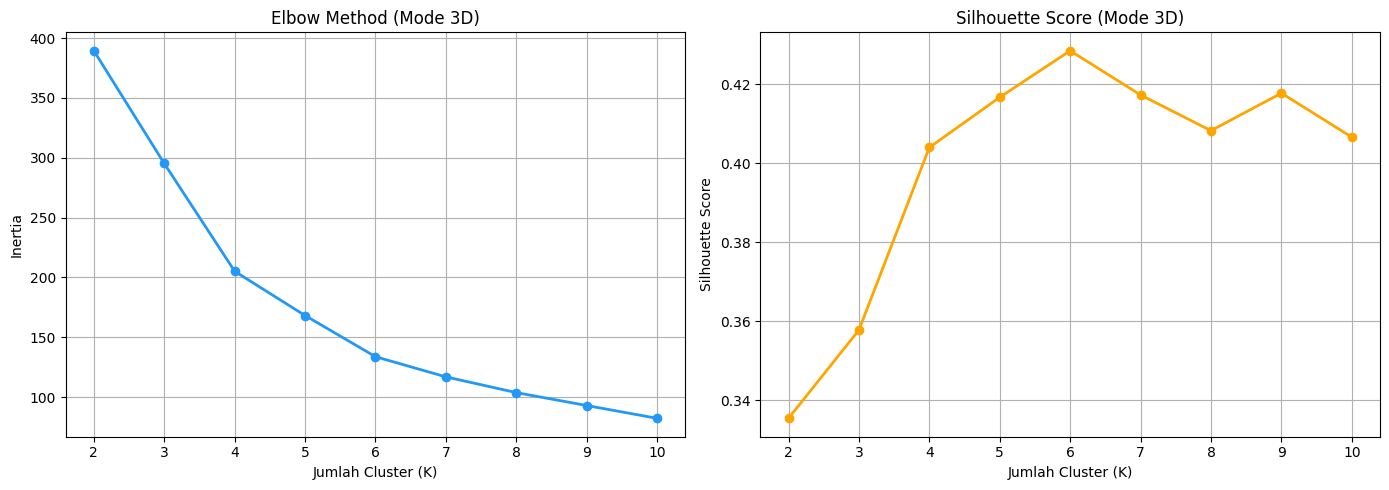

In [19]:
plt.figure(figsize=(14, 5))

# Plot 1: Elbow 3D
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), inertias_3d, marker='o', color='#2398f7', linewidth=2)
plt.title('Elbow Method (Mode 3D)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.grid(True)

# Plot 2: Silhouette 3D
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), sil_scores_3d, marker='o', color='orange', linewidth=2)
plt.title('Silhouette Score (Mode 3D)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

**15. Melatih Model K-Means 3D (K = 6)**

Kita mulai melatih model KMeans 3 fitur, caranya kurang lebih sama dengan yang 2d (2 Fitur), hanya beda di bagian penamaan variabel, jumlah cluster, dan data yang dimasukkan (X Scale) yang telah mencangkup fitur Age/Usia.

In [20]:
# 1. Inisialisasi Model K-Means 3D dengan 6 cluster
kmeans_3d = KMeans(n_clusters=6, init='k-means++', random_state=42, n_init=10)

# 2. Melatih Model sekaligus mendapatkan label clusternya
y_kmeans_3d = kmeans_3d.fit_predict(X_3d_scaled)

print("Hasil Prediksi Cluster:")
print(y_kmeans_3d)

Hasil Prediksi Cluster:
[4 4 5 4 5 4 5 4 5 4 5 4 5 4 5 4 5 4 5 4 5 4 5 4 5 4 5 4 5 4 5 4 5 4 5 4 5
 4 5 4 0 4 5 1 5 4 0 1 1 1 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0
 0 1 0 1 1 0 0 1 0 0 1 0 0 1 1 0 0 1 0 1 1 1 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0
 1 1 1 1 1 0 0 0 0 1 1 1 3 1 3 2 3 2 3 2 3 1 3 2 3 2 3 1 3 2 3 1 3 2 3 2 3
 2 3 2 3 2 3 2 3 2 3 2 3 0 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2
 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3]


**16. Memasukkan Kolom Cluster 3D ke Dataset Aseli**

Sama seperti pada model 2D, bedanya disini kita langsung tambah 1 indeks supaya penomoran clusternya jadi 1 sampai 6

In [21]:
# Masukkan hasil klaster 3D ke dataset asli sebagai kolom baru
df['Cluster_3D'] = y_kmeans_3d + 1

# Kita lihat hasilnya untuk memastikan kolomnya sudah nambah rapi di kanan
df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster_3D']].head()

,Age,Annual Income (k$),Spending Score (1-100),Cluster_3D
0,19,15,39,5
1,21,15,81,5
2,20,16,6,6
3,23,16,77,5
4,31,17,40,6


**17. Menggambar Grafik Visualisasi Scatter Untuk Plot 3D**

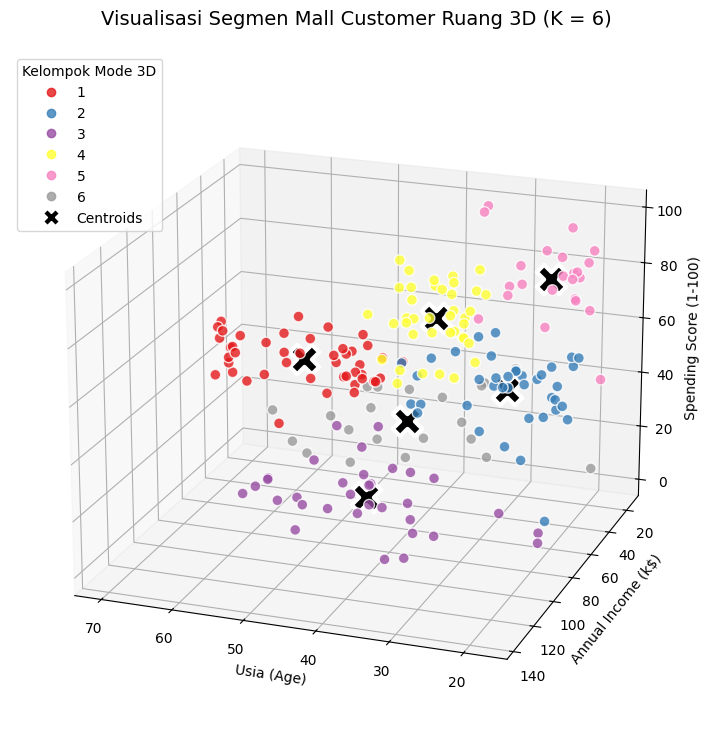

In [22]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.lines as mlines

# 1. Ambil koordinat Centrois skala asli
centroids_3d_scaled = kmeans_3d.cluster_centers_
centroids_3d = scaler_3d.inverse_transform(centroids_3d_scaled)

# 2. Menyiapkan kanvas khusus untuk visual grafik 3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# 3. Plot data titik customer (Warna diatur berdasarkan kolom Cluster_3D)
scatter = ax.scatter(
    df['Age'],
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster_3D'],
    cmap='Set1',
    s=60,
    alpha=0.8,
    edgecolor='white'
)

# 4. Plot titik Centroid asli berbentuk tanda silang 'X'
ax.scatter(
    centroids_3d[:, 0], # Kolom 0 = Rata-rata Usia (Age)
    centroids_3d[:, 1], # Kolom 1 = Rata-rata Pendapatan (Annual Income)
    centroids_3d[:, 2], # Kolom 2 = Rata-rata Skor Spending (Spending Score)
    c='black',
    s=450,
    marker='X',
    edgecolor='white',
    depthshade=False, # Mematikan efek pudar abu-abu warnanya (Secara default True)
    linewidth=3, # Menebalkan garis pinggir
    zorder=99, # Paksa X di gambar lapisan paling depan
    label='Centroids'
)

# 5. Atur teks label sumbu dan judul grafik
ax.set_title('Visualisasi Segmen Mall Customer Ruang 3D (K = 6)', fontsize=14, pad=20)
ax.set_xlabel('Usia (Age)')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')

# Trik Legend Manual Gabungan
# Ambil handles warna kelompok bawaan dari data scatter customer
handles, labels = scatter.legend_elements()

# Membuat penanda legend manual khusus untuk simbol X Centroids
centroid_handle = mlines.Line2D(
    [], [],
    color='black',
    marker='X',
    linestyle='None',
    markersize=12,
    markeredgecolor='white',
    label='Centroids'
)

# Menggabungkan penanda Centroids ke dalam daftar handels legend (kotak keterangan) kita
handles.append(centroid_handle)
labels.append('Centroids')

# Menampilkan legend warna kelompok dan label Centroids
ax.legend(handles=handles, labels=labels, title="Kelompok Mode 3D", loc="upper left")
ax.view_init(elev=20, azim=110) # elev: sudut ketinggian mata memandang (elevasi); azim: sudut rotasi lingkaran grafik (azimuth)

plt.show()

**18. Input Prediksi Data baru (Mode 3D)**

kita mencoba untuk membuat prediksi data baru dalam mode 3 Fitur (3D) ini ketika user ingin mencoba input data baru yang tidak ada di dataset kita dengan model yang telah di train

In [23]:
# Kita buat dictionary cluster 3D untuk memetakan hasil prediksi angka nanti
cluster_labels_3d = {
    1: 'Moderat Senior (Bapak/Emak Belanja Rutin)',
    2: 'Sultan Muda Boros (Target Premium Utama)',
    3: 'Sultan Dewasa Bijak (Rich & Frugal)',
    4: 'Anak Muda Kelas Menengah (Moderat Junior)',
    5: 'Anak Muda Impulsif',
    6: 'Customer Ekonomis (Hemat Total)'
}

# membuat data dummy baru yang di-input (Format: [Age, Annual Income, Spending Score])
# Contoh data: Usia 22 tahun, pendapatan $20k, Skor spending 85
new_cust_3d = np.array([[22, 20, 85]])

# 1. Transformasikan data baru pakai scaler khusus 3d
new_cust_3d_scaled = scaler_3d.transform(new_cust_3d)

# 2. Lakukan prediksi angka cluster menggunakan model final 3D kita
predict_new_3d = kmeans_3d.predict(new_cust_3d_scaled)[0] + 1

# 3. Ambil nama segmen dari dictionary berdasarkan angka hasil prediksi
segment_name_3d = cluster_labels_3d[predict_new_3d]

# 4. Tampilkan hasil prediksi
print(f"Hasil Analisis 3D untuk data {new_cust_3d[0]}:")
print(f"Customer baru ini resmi masuk dalam kelompok {predict_new_3d}: {segment_name_3d}")

Hasil Analisis 3D untuk data [22 20 85]:
Customer baru ini resmi masuk dalam kelompok 5: Anak Muda Impulsif


c:\Users\mufid\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


**19. Export Model & Scaler ke File .pkl**

Setelah melakukan training model baik model 2D maupun 3D, kita mengexport model dan scaler tersebut ke local file supaya bisa lanjut ke tahap pembuatan UI Web App Streamlit

In [24]:
import pickle

# 1. Bungkus komponen untuk Mode 2D (2 Fitur)
with open('../models/scaler_2d.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../models/kmeans_2d.pk', 'wb') as f:
    pickle.dump(kmeans, f)

# 2. Bungkus komponen untuk Mode 3D (3 Fitur)
with open('../models/scaler_3d.pkl', 'wb') as f:
    pickle.dump(scaler_3d, f)

with open('../models/kmeans_3d.pkl', 'wb') as f:
    pickle.dump(kmeans_3d, f)

print("Semua model dan scaler resmi dibungkus menjadi file .pkl!")

Semua model dan scaler resmi dibungkus menjadi file .pkl!
